## PRE-Training on Unlabeled Data

In [1]:
from previous_chapters import GPTModel, GPTDataset 
import tiktoken
import torch

In [2]:
GPT_CONFIG_124M = {
    "vocab_size": 50257,   # Vocabulary size
    "context_len": 256, # Shortened context length (orig: 1024)
    "emb_dim": 768,        # Embedding dimension
    "heads": 12,         # Number of attention heads
    "tranf_blocks": 4,        # Number of layers
    "dropout_rate": 0.1,      # Dropout rate
    "qkv_bias": False      # Query-key-value bias
}


In [3]:
import torch
import torch.nn as nn

class RMSNorm(nn.Module):
    def __init__(self,dim):
        super().__init__()
        self.shift = nn.Parameters(torch.ones(dim))
        self.eps = 1e-5

    def forward(self, x):
        rms = torch.mean(x**2, dim=-1) + self.eps 
        rms_root = torch.sqrt(rms)
        return x/rms_root * self.shift

In [4]:
model = GPTModel(GPT_CONFIG_124M)
model.eval()

GPTModel(
  (tok_emb): Embedding(50257, 768)
  (pos_emb): Embedding(256, 768)
  (drop_embeds): Dropout(p=0.1, inplace=False)
  (traf_blocks): Sequential(
    (0): TransformerBlock(
      (ffn): FeedForwardN(
        (l1): Linear(in_features=768, out_features=3072, bias=True)
        (gelu): GELU(approximate='none')
        (l2): Linear(in_features=3072, out_features=768, bias=True)
      )
      (mha): MultiHeadAttention(
        (Wk): Linear(in_features=768, out_features=768, bias=True)
        (Wq): Linear(in_features=768, out_features=768, bias=True)
        (Wv): Linear(in_features=768, out_features=768, bias=True)
        (dropout): Dropout(p=0.1, inplace=False)
        (out_proj): Linear(in_features=768, out_features=768, bias=True)
      )
      (drop_embeds): Dropout(p=0.1, inplace=False)
      (norm1): LayerNorm()
      (norm2): LayerNorm()
    )
    (1): TransformerBlock(
      (ffn): FeedForwardN(
        (l1): Linear(in_features=768, out_features=3072, bias=True)
        (g

In [5]:
from torch.utils.data import DataLoader 

def create_dataloader(txt, bs=4, max_len=256, stride=128, 
                      shuffle=True, drop_last=True, 
                      num_workers=0):

    tokenizer = tiktoken.get_encoding("gpt2")

    dataset = GPTDataset(txt, tokenizer, max_len, stride)
    
    dataloader = DataLoader(
        dataset,
        batch_size=bs,
        shuffle=shuffle,
        drop_last=drop_last,
        num_workers=num_workers
    ) 

    return dataloader

In [6]:
sent = "Every effor moves you forward"
dataload = create_dataloader(sent, max_len=3, stride=1, bs=2)
it = iter(dataload)

In [7]:
data, trgts = next(it)
data, trgts

(tensor([[ 273, 6100,  345],
         [6109,  914,  273]]),
 tensor([[6100,  345, 2651],
         [ 914,  273, 6100]]))

In [8]:
tokenizer = tiktoken.get_encoding("gpt2")
# tokenizer.decode(seq[1])

NameError: name 'seq' is not defined

In [9]:
def tokens_to_text(ids, tokenizer):
    return tokenizer.decode(ids.squeeze(0).tolist()) 

def text_to_tokenIds(text, tokenizer):
    return torch.tensor(tokenizer.encode(text)).unsqueeze(0)

# tokns = text_to_tokenIds(sent, tokenizer)

In [10]:
token_ids = generate_text(model, tokns, 3, 2)

NameError: name 'generate_text' is not defined

In [ ]:
token_ids

In [11]:
with open("chats_data.txt", "r") as f:
    text = f.read()
small_text = text[-10000:]
len(small_text)
    

10000

In [12]:
print(len(val_data))
GPT_CONFIG_124M["context_len"]

NameError: name 'val_data' is not defined

In [13]:
len(tokenizer.encode(val_data))

NameError: name 'val_data' is not defined

In [14]:
train_ratio = 0.9
split_idx = int(train_ratio * len(small_text))
train_data = small_text[:split_idx]
val_data = small_text[split_idx:]

train_dataloader = create_dataloader(train_data, bs=2 , max_len=GPT_CONFIG_124M["context_len"], stride=GPT_CONFIG_124M["context_len"], shuffle=True, drop_last=True)
val_dataloader = create_dataloader(val_data, bs=2, max_len=GPT_CONFIG_124M["context_len"], stride=GPT_CONFIG_124M["context_len"], shuffle=False, drop_last=False)

t_it = iter(train_dataloader)
v_it = iter(val_dataloader)

print(len(train_dataloader), len(val_dataloader))



6 1


In [15]:
len(tokenizer.encode(small_text))

3946

In [16]:
total_tokens = len(tokenizer.encode(small_text))

if total_tokens * (train_ratio) < GPT_CONFIG_124M["context_len"]:
    print("Not enough tokens for the training loader. "
          "Try to lower the `GPT_CONFIG_124M['context_length']` or "
          "increase the `training_ratio`")

if total_tokens * (1-train_ratio) < GPT_CONFIG_124M["context_len"]:
    print("Not enough tokens for the validation loader. "
          "Try to lower the `GPT_CONFIG_124M['context_length']` or "
          "decrease the `training_ratio`")

In [17]:
for x, y in train_dataloader:
    print(x.shape, y.shape)

torch.Size([2, 256]) torch.Size([2, 256])
torch.Size([2, 256]) torch.Size([2, 256])
torch.Size([2, 256]) torch.Size([2, 256])
torch.Size([2, 256]) torch.Size([2, 256])
torch.Size([2, 256]) torch.Size([2, 256])
torch.Size([2, 256]) torch.Size([2, 256])


In [18]:
def calc_loss_batch(input_batch, target_batch, model, device):
    input_batch, target_batch = input_batch.to(device), target_batch.to(device)
    print(input_batch.shape)
    logits = model(input_batch)
    loss = torch.nn.functional.cross_entropy(logits.flatten(0, 1), target_batch.flatten(0))
    return loss

def calc_loss_loader(loader, model, device, num_batches=None):
    total_loss = 0
    if len(loader) == 0:
        return float("nan")

    elif num_batches == None:
        num_batches = len(loader)
        
    else:
        num_batches = min(num_batches, len(loader))

    for i, (input_batch, target_batch) in enumerate(loader):
        if i < num_batches:
            loss = calc_loss_batch(input_batch, target_batch, model, device)
            total_loss += loss.item()

        else:
            break
    return total_loss / num_batches 
        

In [19]:
len(val_dataloader)

1

In [20]:
model.to("cuda")

with torch.no_grad():
    train_loss=calc_loss_loader(train_dataloader, model, "cuda")
    val_loss=calc_loss_loader(val_dataloader, model, "cuda")

print(f"Train loss: {train_loss}, {val_loss}")


torch.Size([2, 256])
Going to Traf Block: torch.Size([2, 256, 768])
FFn out:  torch.Size([2, 256, 768])
FFn out:  torch.Size([2, 256, 768])
FFn out:  torch.Size([2, 256, 768])
FFn out:  torch.Size([2, 256, 768])
torch.Size([2, 256])
Going to Traf Block: torch.Size([2, 256, 768])
FFn out:  torch.Size([2, 256, 768])
FFn out:  torch.Size([2, 256, 768])
FFn out:  torch.Size([2, 256, 768])
FFn out:  torch.Size([2, 256, 768])
torch.Size([2, 256])
Going to Traf Block: torch.Size([2, 256, 768])
FFn out:  torch.Size([2, 256, 768])
FFn out:  torch.Size([2, 256, 768])
FFn out:  torch.Size([2, 256, 768])
FFn out:  torch.Size([2, 256, 768])
torch.Size([2, 256])
Going to Traf Block: torch.Size([2, 256, 768])
FFn out:  torch.Size([2, 256, 768])
FFn out:  torch.Size([2, 256, 768])
FFn out:  torch.Size([2, 256, 768])
FFn out:  torch.Size([2, 256, 768])
torch.Size([2, 256])
Going to Traf Block: torch.Size([2, 256, 768])
FFn out:  torch.Size([2, 256, 768])
FFn out:  torch.Size([2, 256, 768])
FFn out:  to

In [21]:
from previous_chapters import generate_text 
def train_model_simple(model, train_loader, val_loader, optimizer, device, num_epo,
                      eval_freq, eval_iter, start_context, tokenizer):
    train_losses, val_losses, track_tokens_seen = [], [], []
    tokens_seen, global_step = 0, -1

    for epoch in range(num_epochs):
        model.train()

        for input_batch, target_batch in train_loader:
            optimizer.zero_grad()
            loss = calc_loss_batch(input_batch, target_batch, model, device)
            loss.backward()
            optimizer.step()
            tokens_seen += input_batch.numel()
            global_step += 1


            if global_step % eval_freq == 0:
                train_loss, val_loss = evaluate_model(
                    model, train_loader, val_loader, device, eval_iter)
                train_losses.append(train_loss)
                val_losses.append(val_loss)
                track_tokens_seen.append(tokens_seen)
                print(f"Ep {epoch+1} Step: {global_step:06d}): "
                        f"Train loss {train_loss:.3f}, Val loss {val_loss:.3f}")
                
            generate_and_print_sample(model, tokenizer, device, start_context)

    return train_losses, val_losses, track_tokens_seen   

def evaluate_model(model, train_loader, val_loader, device, eval_iter):
    model.eval()
    with torch.no_grad():
        train_loss = calc_loss_loader(train_dataloader, model, device, num_batches=eval_iter)
        val_loss = calc_loss_loader(val_dataloader, model, device, num_batches=eval_iter)
    model.train()
    return train_loss, val_loss
        
        

def generate_and_print_sample(model, tokenizer, device, start_context):
    model.eval()
    context_size = model.pos_emb.weight.shape[0]
    encoded = text_to_tokenIds(start_context, tokenizer).to(device)
    with torch.no_grad():
        token_ids = generate_text(
            model = model, idx = encoded, 
            max_new_tokens=50, context_size=context_size
        )
    decoded_text = tokens_to_text(token_ids, tokenizer)
    print(decoded_text.replace("\n", " "))
    model.train()

        

In [22]:
device = "cuda"
import time
start_time = time.time()

torch.manual_seed(123)
model = GPTModel(GPT_CONFIG_124M)
model.to(device)
optimizer = torch.optim.AdamW(model.parameters(), lr=0.0004, weight_decay=0.1)
num_epochs = 10
trian_losses, val_losses, tokens_seen = train_model_simple(model=model, train_loader=train_dataloader, val_loader=val_dataloader, 
                                                           optimizer=optimizer, device=device, num_epo=10, 
                                                           eval_freq=5, eval_iter=5, start_context="Real. ", tokenizer=tokenizer)
end_time = time.time()
exec_time = (end_time - start_time)/60
print(f"Training completed in {exec_time:.2f} minutes.")


torch.Size([2, 256])
Going to Traf Block: torch.Size([2, 256, 768])
FFn out:  torch.Size([2, 256, 768])
FFn out:  torch.Size([2, 256, 768])
FFn out:  torch.Size([2, 256, 768])
FFn out:  torch.Size([2, 256, 768])
torch.Size([2, 256])
Going to Traf Block: torch.Size([2, 256, 768])
FFn out:  torch.Size([2, 256, 768])
FFn out:  torch.Size([2, 256, 768])
FFn out:  torch.Size([2, 256, 768])
FFn out:  torch.Size([2, 256, 768])
torch.Size([2, 256])
Going to Traf Block: torch.Size([2, 256, 768])
FFn out:  torch.Size([2, 256, 768])
FFn out:  torch.Size([2, 256, 768])
FFn out:  torch.Size([2, 256, 768])
FFn out:  torch.Size([2, 256, 768])
torch.Size([2, 256])
Going to Traf Block: torch.Size([2, 256, 768])
FFn out:  torch.Size([2, 256, 768])
FFn out:  torch.Size([2, 256, 768])
FFn out:  torch.Size([2, 256, 768])
FFn out:  torch.Size([2, 256, 768])
torch.Size([2, 256])
Going to Traf Block: torch.Size([2, 256, 768])
FFn out:  torch.Size([2, 256, 768])
FFn out:  torch.Size([2, 256, 768])
FFn out:  to

In [23]:
model.eval()

GPTModel(
  (tok_emb): Embedding(50257, 768)
  (pos_emb): Embedding(256, 768)
  (drop_embeds): Dropout(p=0.1, inplace=False)
  (traf_blocks): Sequential(
    (0): TransformerBlock(
      (ffn): FeedForwardN(
        (l1): Linear(in_features=768, out_features=3072, bias=True)
        (gelu): GELU(approximate='none')
        (l2): Linear(in_features=3072, out_features=768, bias=True)
      )
      (mha): MultiHeadAttention(
        (Wk): Linear(in_features=768, out_features=768, bias=True)
        (Wq): Linear(in_features=768, out_features=768, bias=True)
        (Wv): Linear(in_features=768, out_features=768, bias=True)
        (dropout): Dropout(p=0.1, inplace=False)
        (out_proj): Linear(in_features=768, out_features=768, bias=True)
      )
      (drop_embeds): Dropout(p=0.1, inplace=False)
      (norm1): LayerNorm()
      (norm2): LayerNorm()
    )
    (1): TransformerBlock(
      (ffn): FeedForwardN(
        (l1): Linear(in_features=768, out_features=3072, bias=True)
        (g

In [24]:
train_losses = trian_losses

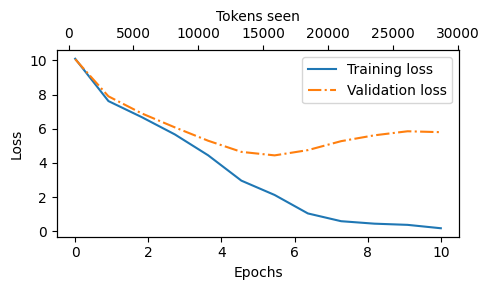

In [25]:
import matplotlib.pyplot as plt
from matplotlib.ticker import MaxNLocator


def plot_losses(epochs_seen, tokens_seen, train_losses, val_losses):
    fig, ax1 = plt.subplots(figsize=(5, 3))

    # Plot training and validation loss against epochs
    ax1.plot(epochs_seen, train_losses, label="Training loss")
    ax1.plot(epochs_seen, val_losses, linestyle="-.", label="Validation loss")
    ax1.set_xlabel("Epochs")
    ax1.set_ylabel("Loss")
    ax1.legend(loc="upper right")
    ax1.xaxis.set_major_locator(MaxNLocator(integer=True))  # only show integer labels on x-axis

    # Create a second x-axis for tokens seen
    ax2 = ax1.twiny()  # Create a second x-axis that shares the same y-axis
    ax2.plot(tokens_seen, train_losses, alpha=0)  # Invisible plot for aligning ticks
    ax2.set_xlabel("Tokens seen")

    fig.tight_layout()  # Adjust layout to make room
    plt.savefig("loss-plot.pdf")
    plt.show()

epochs_tensor = torch.linspace(0, num_epochs, len(train_losses))
plot_losses(epochs_tensor, tokens_seen, trian_losses, val_losses)

In [32]:
inference_device = "cpu"
model.to(inference_device)
model.eval()

tokenizer = tiktoken.get_encoding("gpt2")

token_ids = generate_text(
    model=model,
    idx=text_to_tokenIds("kya?", tokenizer).to(inference_device),
    max_new_tokens=500,
    context_size=GPT_CONFIG_124M["context_len"]
)

print("Output text:\n", tokens_to_text(token_ids, tokenizer))

Going to Traf Block: torch.Size([1, 3, 768])
FFn out:  torch.Size([1, 3, 768])
FFn out:  torch.Size([1, 3, 768])
FFn out:  torch.Size([1, 3, 768])
FFn out:  torch.Size([1, 3, 768])
Going to Traf Block: torch.Size([1, 4, 768])
FFn out:  torch.Size([1, 4, 768])
FFn out:  torch.Size([1, 4, 768])
FFn out:  torch.Size([1, 4, 768])
FFn out:  torch.Size([1, 4, 768])
Going to Traf Block: torch.Size([1, 5, 768])
FFn out:  torch.Size([1, 5, 768])
FFn out:  torch.Size([1, 5, 768])
FFn out:  torch.Size([1, 5, 768])
FFn out:  torch.Size([1, 5, 768])
Going to Traf Block: torch.Size([1, 6, 768])
FFn out:  torch.Size([1, 6, 768])
FFn out:  torch.Size([1, 6, 768])
FFn out:  torch.Size([1, 6, 768])
FFn out:  torch.Size([1, 6, 768])
Going to Traf Block: torch.Size([1, 7, 768])
FFn out:  torch.Size([1, 7, 768])
FFn out:  torch.Size([1, 7, 768])
FFn out:  torch.Size([1, 7, 768])
FFn out:  torch.Size([1, 7, 768])
Going to Traf Block: torch.Size([1, 8, 768])
FFn out:  torch.Size([1, 8, 768])
FFn out:  torch.

In [37]:
next_token_logits = torch.tensor(
    [4.51, 0.89, -1.90, 6.75, 1.63, -1.62, -1.89, 6.28, 1.79]
)

probas = torch.softmax(next_token_logits, dim=0)
torch.multinomial(probas, num_samples=1).item()

3